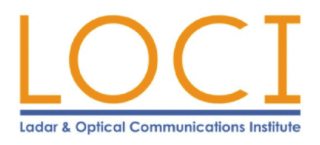

# Function: Photons Returned 

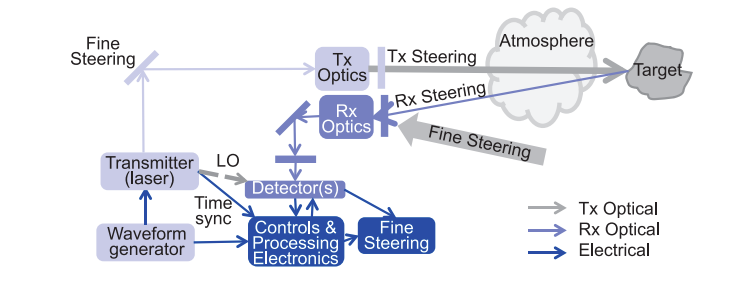

In [1]:
#Importing libraries

import math
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, Layout, widgets
import matplotlib.image as mpimg

#setting constants
#HV = 5000  #Human Visibility (m) number
#EPP = 0.2   #Energy per pulse (mjoule) number
#RAD = 25   #Receiver Aperture Diameter (mm) number
NUMPT = 100 #number of points on graph



def datafunc (HV, EPP, RAD):
   
    if (EPP < 0) : 
        EPP = 0

    def plot_func(Range_Low,Range_High): #print('start plot func')

        #calculations
        B55 = -(math.log(0.05))/HV #idk find out
        B155 = B55*(1.55/0.55)**-(0.1428*1.55-0.0947) #idk find out
        SS = (Range_High - Range_Low)/NUMPT
        #print('start loop')
        PRList = np.zeros(NUMPT)
        IRList = np.zeros(NUMPT)
        for cnt in range (0,NUMPT) : 
            IRTEMP = Range_Low + cnt*SS
            OWT = math.exp(-B155*IRTEMP)  #One Way Transmission
            TWT = OWT**2 #Two Way Transmission
            PR = EPP*0.001*(0.1/64**2)*((0.001*RAD)/(IRTEMP)**2*(0.00000155/(300000000*6.64E-34)*TWT*0.6))   #number of photons received from a 10% reflective object
            #print('Photons Returned = ', PR,'IRTEMP = ',IRTEMP, 'count = ',cnt)
            PRList[cnt] = PR 
            IRList[cnt] = IRTEMP
            cnt +=1
           # print('now n=',cnt , NUMPT)


        fig, ax = plt.subplots(figsize=(12,5))
        plt.title('Photons Returned')
        plt.ylabel('# of Photons Returned')
        plt.xlabel('Range - M')
        plt.axis([Range_Low, Range_High,0,max(PRList)])
        plt.plot (IRList, PRList,':r',linewidth=3)

          #plt.plot (x1 , y,color = 'Blue')
                  #  plt.plot (x2 , y, color = 'Green')
                   # plt.plot([O1,0.9*O2],[Alt*0.01,Alt*0.01], linewidth=5, color='purple')
                    #plt.text(O1,0,'|',color='black')
                #    plt.text(Alt*1.2,Alt*.85,'         Slant Range = ' + str(H1R),color='blue')
                  #  plt.text(Alt*1.2,Alt*.75,'              Flat GSD = ' + str(ogsdr),color='purple')
                  #  plt.text(Alt*1.2,Alt*.65,'           Arc Lenght = ' + str(arclnr),color='purple')
                  #  plt.text(Alt*1.2,Alt*.55,'   Down Rang Dist = ' + str(o1r),color='black')
              #  else: 

        #print('end of loop', PRList)
    #The slider
    interact(plot_func,
                Range_Low = widgets.FloatSlider(value=30, min=10, max=1000, step=10,continuous_update = False),
                Range_High = widgets.FloatSlider(value=100, min=10, max=1000, step=10, continuous_update = False),
                )

style1 = {'description_width': 'initial'} 
interact(datafunc,
             HV = widgets.FloatText(value=5000, step=1, description = 'Human Visibility(m)',style=style1),
             EPP = widgets.FloatText(value=0.2, min = 0, step=0.25, description = 'Energy Per Pulse(mJ)',style=style1),
             RAD = widgets.FloatText(value=25, step=0.05, description = 'Receiver Aperture Diameter(m)',style=style1),
            ) 

#print('done')

        


NameError: name 'style1' is not defined

# Code By Ryan Devitt